(irk-exercises-section)=

# Implicit Runge-Kutta methods exercises


`````{exercise}
:label: ch3-ex-radauIA-order

Determine the order of the DIRK method shown below.

$$ \begin{array}{c|cc}
    \frac{1}{4} & \frac{1}{4} \\
    \frac{3}{4} & \frac{1}{2} & \frac{1}{4} \\ \hline
    & \frac{1}{2} & \frac{1}{2}
\end{array} $$

```{dropdown} Solution
Checking $B(k)$ condition

$$ \begin{align*}
    k &= 1: & LHS &= b_1c_1^0 + b_2c_2^0 = \frac{1}{2} + \frac{1}{2} = 1, \\
    && RHS &= 1 \qquad \checkmark \\
    k &= 2: & LHS &= b_1c_1 + b_2c_2 = \frac{1}{2}\cdot \frac{1}{4} + \frac{1}{2} \cdot \frac{3}{4} = \frac{1}{2}, \\
    && RHS &= \frac{1}{2} \qquad \checkmark \\
    k &= 3: & LHS &= b_1c_1^2 + b_2c_2^2 = \frac{1}{2} \cdot \frac{1}{16} + \frac{1}{2} \cdot \frac{9}{16} = \frac{5}{16}, \\
    && RHS &= \frac{1}{3}. \qquad \mathsf{x}
\end{align*} $$

Checking $C(1)$ condition

$$ \begin{align*}
    i &= 1: & LHS &= a_{11} + a_{12} = \frac{1}{4} + 0 = \frac{1}{4}, \\
    && RHS &= \frac{1}{1} c_1^1 = \frac{1}{4} \qquad \checkmark \\
    i &= 2: & LHS &= a_{21} + a_{22} = \frac{1}{2} + \frac{1}{4} = \frac{3}{4}, \\
    && RHS &= \frac{1}{1} c_2^1 = \frac{3}{4}. \qquad \checkmark
\end{align*} $$

Checking $D(1)$ condition

$$ \begin{align*}
    j &=1: & LHS &= b_1c_1^0a_{11} + b_2c_2^0a_{21} = \frac{1}{2} \cdot \frac{1}{4} + \frac{1}{2} \cdot \frac{1}{2} = \frac{3}{8}, \\
    && RHS &= \frac{1}{1}b_1(1-c_1^1) = \frac{1}{2}\left( 1 - \frac{1}{4} \right) = \frac{3}{8} \qquad \checkmark \\
    j &= 2: & LHS &= b_1c_1^0a_{12} + b_2c_2^0a_{22} = \frac{1}{2} \cdot 0 + \frac{1}{2} \cdot \frac{1}{4} = \frac{1}{8}, \\
    && RHS &= \frac{1}{1}b_2(1 - c_2^1) = \frac{1}{2} \left( 1 - \frac{3}{4} \right) = \frac{1}{8}. \qquad \checkmark
\end{align*} $$

Since $B(2)$, $C(1)$ and $D(1)$ conditions are all satisfied then this DIRK method is a second-order method.
```
`````

```````{exercise}
:label: ch3-ex-radauIIA-derivation

Derive a third-order Radau IIA method. Present your method in a Butcher tableau.

``````{dropdown} Solution

A third-order Radau IIA method requires $s = 2$ stages. The $c_1$ and $c_2$ coefficients are the roots of the Legendre polynomial $P_2(x) - P_1(x) = 0$

$$ \begin{align*}
    0 &= 1 + {2 \choose 1} {3 \choose 1} (x - 1) + {2 \choose 2} {4 \choose 2}(x - 1)^2 - 1 - {1 \choose 1} {2 \choose 1}(x - 1) \\
    &= 1 + 6(x - 1) + 6(x - 1)^2 - 1 - 2(x - 1) \\
    &= 6x^2 - 8x + 2 \\
    &= (3x - 1)(2x - 2).
\end{align*} $$

therefore $c_1 = \frac{1}{3}$ and $c_2 = 1$. The $a_{ij}$ and $b_i$ coefficients are chosen to satisfy the $B(3)$ and $C(2)$ conditions respectively

$$ \begin{align*}
    b_1 + b_2 &= 1, \\
    b_1c_1 + b_2c_2 &= \tfrac{1}{2}, \\
    a_{11} + b_{12} &= c_1, \\
    a_{21} + b_{22} &= c_2, \\
    a_{11}c_1 + a_{12}c_j &= \tfrac{1}{2}c_1^2, \\
    a_{21}c_1 + a_{22}c_2 &= \tfrac{1}{2}c_2^2.
\end{align*} $$

Note that we did not need all equations from the $B(3)$ condition since we only have 6 unknowns. Using Python or MATLAB to solve these gives

$$ \begin{array}{c|cc}
    \frac{1}{3} & \frac{5}{12} & -\frac{1}{12} \\
    1 & \frac{3}{4} & \frac{1}{4} \\ \hline
    & \frac{3}{4} & \frac{1}{4}
\end{array} $$

`````{tab-set}
````{tab-item} Python
```python
import sympy as sp

# Define symbolic variables
a11, a12, a21, a22, b1, b2, c1, c2, x = sp.symbols("a11, a12, a21, a22, b1, b2, c1, c2, x")
c1 = sp.Rational(1, 3)
c2 = 1

# Define order conditions
eq1 = b1 + b2 - 1
eq2 = b1 * c1 + b2 * c2 - sp.Rational(1,2)
eq3 = a11 + a12 - c1
eq4 = a21 + a22 - c2
eq5 = a11 * c1 + a12 * c2 - sp.Rational(1,2) * c1 ** 2
eq6 = a21 * c1 + a22 * c2 - sp.Rational(1,2) * c2 ** 2

# Solve order conditions
sp.solve((eq1, eq2, eq3, eq4, eq5, eq6))
```
````

`````

``````
```````


In [3]:
import sympy as sp

# Define symbolic variables
a11, a12, a21, a22, b1, b2, c1, c2, x = sp.symbols("a11, a12, a21, a22, b1, b2, c1, c2, x")
c1 = sp.Rational(1, 3)
c2 = 1

# Define order conditions
eq1 = b1 + b2 - 1
eq2 = b1 * c1 + b2 * c2 - sp.Rational(1,2)
eq3 = a11 + a12 - c1
eq4 = a21 + a22 - c2
eq5 = a11 * c1 + a12 * c2 - sp.Rational(1,2) * c1 ** 2
eq6 = a21 * c1 + a22 * c2 - sp.Rational(1,2) * c2 ** 2

# Solve order conditions
sp.solve((eq1, eq2, eq3, eq4, eq5, eq6))

{a11: 5/12, a12: -1/12, a21: 3/4, a22: 1/4, b1: 3/4, b2: 1/4}


`````{exercise}
:label: ch3-ex-stiff

Consider following IVP

$$ \begin{align*}
  y_1' &= -1000 y_1 + y_2, & y_1(0) &= 1, \\
  y_2' &= -y_2, & y_2(0) &= 1.
\end{align*} $$

(a) &emsp; Compute the solution to this IVP over $t\in [0, 5]$ using the Radau IIA method from the previous exercise with a step length of $h = 0.1$. Produce a plot of the solutions to $y_1$ and $y_2$ against $t$.

````{dropdown} Solution
```{glue:figure} ex3.3_plot_radauIIA
```
````

(b) &emsp; Attempt to solve this IVP using the RK4 method with the same step length. What do you notice about the result?

````{dropdown} Solution
```{glue:figure} ex3.3_plot_rk4
```
The solution is unstable.
````

(c) &emsp; Solve this IVP using the {prf:ref}`Fehlberg 4(5)<fehlbergs-method-equation>` explicit Runge-Kutta method. Record the time taken for both methods to compute the solution and determine value of the smallest step length used in the Fehlberg's method solution. What does this suggest about this system?

````{dropdown} Solution
The Radau IIA method took 0.005 seconds to compute whereas the Runge-Kutta Fehlberg 4(5) method took 0.051 seconds to compute (these times will vary depending on the machine used). The smallest step length used in Fehlberg's method was $h = 0.000427$. This suggests that this is a stiff system since the minimum step length used in Fehlberg's method is very small compared to the one used for the Radau IIA method.
````
`````

<!-- `````{exercise}
:label: ch3-ex-robertson

The {cite:t}`robertson:1966` model describes the following chemical reaction between three chemicals

$$ \begin{align*}
    A &\xrightarrow{k_1} B, \\
    B &\xrightarrow{k_2} C, \\
    B + B &\xrightarrow{k_3} C,
\end{align*} $$

where $A$, $B$ and $C$ are the concentration of the three chemicals and $k_1 = 0.04$, $k_2 = 3 \times 10^{7}$ and $k_3 = 10^{4}$ are parameters determining the reaction rates. Writing these as a system of ODEs gives

$$ \begin{align*}
    \frac{\mathrm{d}A}{\mathrm{d}t} &= -k_1A, \\
    \frac{\mathrm{d}B}{\mathrm{d}t} &= k_1A - k_2B - k_3B^2, \\
    \frac{\mathrm{d}C}{\mathrm{d}t} &= k_2B + k_3B^2.
\end{align*} $$

(a) &emsp; Write a Python or MATLAB program to solve the Robertson model over $t \in [0, 100]$, with initial values $A(0) = 1$ and $B(0) = C(0) = 0$ using the Radau IIA model from {ref}`ch3-ex-radauIIA-derivation` with a step length of $h = 1$. Produce a plot of the concentrations of the three chemicals over $t$ on the same axes, with $B$ multiplied by a scaling factor of $10^5$ so that it is visible on the plot.

````{dropdown} Solution
```{glue:figure} ex3.3_plot
```
````

(b) &emsp; Solve the same IVP using the [Fehlberg 5(4) ERK method](ssc-code-section). Determine the smallest step length used throughout the solution.

```{dropdown} Solution
The smallest step length used by the Fehlberg 5(4) method was $h = 1.48 \times 10^{-4}$
```


(c) &emsp; Comment on the applicability of the two methods used here to solve this IVP. Why do your think one method took longer than the other?

```{dropdown} Solution
The Fehlberg 5(4) ERK method took much longer than the Radau IIA IRK method to compute the solution. This was because the chemical reaction is violent as indicated by the plot of the solution which shows the concentration of $B$ increasing rapidly shortly after the start of the reaction. This means the Fehlberg 5(4) ERK method is having to use a very small step length to ensure a stable solution. The Robertson model is an example of a stiff problem which the Radau class of IRK methods are more suited to solving than an ERK method (stiffness is covered in the [next chapter](stiffness-section)).
```
````` -->


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

def jac(f, t, y):
    J = np.zeros((len(y), len(y)))
    epsilon = 1e-6
    for i in range(len(y)):
        y_plus_epsilon = y.astype(float)
        y_plus_epsilon[i] += epsilon
        J[:,i] = (f(t, y_plus_epsilon) - f(t,y)) / epsilon

    return J


def radauIIA(f, tpsan, y0, h):
    
    # Determine the number of ODEs in the system
    N = len(y0)

    # Calculate the number of steps required
    nsteps = int((tspan[1] - tspan[0]) / h)

    # Define solution arrays and assign initial values
    t = np.zeros(nsteps + 1)
    y = np.zeros((nsteps + 1, N))
    t[0] = tspan[0]
    y[0,:] = y0
    
    # Define Butcher tableau
    A = np.array([[1/4, -1/4],
                  [1/4, 5/12]])
    b = np.array([1/4, 3/4])
    c = np.array([0, 2/3])
    s = 2

    # Define maximum Newton iterations
    max_iter = 10

    # Loop through steps
    for n in range(nsteps):

        # Use Newton's method to solve for the stage values
        Y = np.zeros(N * s)
        F = np.zeros(N * s)
        e = np.ones(N)
        J = jac(f, t[n], y[n,:])

        for k in range(max_iter):
            F[:N] = f(t[n] + c[0] * h, Y[:N])
            F[N:] = f(t[n] + c[1] * h, Y[N:])
            g = Y - np.kron(e, y[n,:]) - h * np.kron(A, np.eye(N)) @ F
            delta_Y = np.linalg.solve(np.eye(N * s) - h * np.kron(A, J), -g)
            Y += delta_Y
            if np.linalg.norm(delta_Y) < 1e-6:
                break
        
        y[n+1,:] = y[n,:] + h * np.kron(b.T, np.eye(N)) @ F
        t[n+1] = t[n] + h

    return t, y


# Define RK4 method function
def rk4(f, tspan, y0, h):

    nsteps = int((tspan[1] - tspan[0]) / h)
    m = len(y0)
    t = np.zeros(nsteps + 1)
    y = np.zeros((nsteps + 1, m))

    t[0] = tspan[0]
    y[0,:] = y0
    
    for n in range(nsteps):
        k1 = f(t[n], y[n,:])
        k2 = f(t[n] + 0.5 * h, y[n,:] + 0.5 * h * k1)
        k3 = f(t[n] + 0.5 * h, y[n,:] + 0.5 * h * k2)
        k4 = f(t[n] + h, y[n,:] + h * k3)
        y[n+1,:] = y[n,:] + h / 6 * (k1 + 2 * k2 + 2 * k3 + k4);
        t[n+1] = t[n] + h

    return t, y


def rkf45(f, tspan, y0, atol=1e-6, rtol=1e-3):

    # Determine the number of ODEs in the system
    N = len(y0)

    # Define solution arrays and assign initial values
    max_steps = 100000
    t = np.zeros(max_steps + 1)
    y = np.zeros((max_steps + 1, N))
    t[0] = tspan[0]
    y[0,:] = y0
    
    # Compute initial step length
    h = 0.8 * rtol ** (1 / 3)

    # Loop through steps
    n = 0
    while t[n] < tspan[-1]:

        # Compute the stage values
        k1 = f(t[n], y[n,:])
        k2 = f(t[n] + 1/4 * h, y[n,:] + 1/4 * h * k1)
        k3 = f(t[n] + 3/8 * h, y[n,:] + h * (3/32 * k1 + 9/32 * k2))
        k4 = f(t[n] + 12/13 * h, y[n,:] + h * (1932/2197 * k1 - 7200/2197 * k2 + 7296/2197 * k3))
        k5 = f(t[n] + h, y[n,:] + h * (439/216 * k1 - 8 * k2 + 3680/513 * k3 - 845/4104 * k4))
        k6 = f(t[n] + 1/2 * h, y[n,:] + h * (-8/27 * k1 + 2 * k2 - 3544/2565 * k3 + 1859/4104 * k4 - 11/40 * k5))

        # Compute the 4th and 5th order solutions for the next step
        y5 = y[n,:] + h * (16/235 * k1 + 6656/12825 * k3 + 28561/56430 * k4 - 9/50 * k5 + 2/55 * k6)
        y4 = y[n,:] + h * (25/216 * k1 + 1408/2565 * k3 + 2197/4104 * k4 - 1/5 * k5)

        print(y5.shape)
        # Compute delta and tol
        delta = np.linalg.norm(y5 - y4)
        tol = atol + rtol * np.min(np.abs(y5))

        # Check if current step was successful
        if delta < tol:
            y[n+1,:] = y5
            t[n+1] = t[n] + h
            n += 1
        
        # Update h
        r = max(0.1, 0.8 * (tol / delta) ** (1/5))
        h = min(r * h, tspan[-1] - t[n])

    return t[:n+1], y[:n+1,:]


def f(t, y):
    return np.array([-1000 * y[0] + y[1], -y[1]])

# Define IVP
tspan = [0, 5]
y0 = [1, 1]
h = 0.1

# Solve IVP
start = time.time()
t_rk4, y_rk4 = rk4(f, tspan, y0, 1)
rk4_time = time.time() - start

start = time.time()
t_rkf45, y_rkf45 = rkf45(f, tspan, y0)
rkf45_time = time.time() - start

start = time.time()
t, y_radauIIA = radauIIA(f, tspan, y0, h)
radauIIA_time = time.time() - start

print(f"RK4 time: {rk4_time:0.3f}")
print(f"RKF45 time: {rkf45_time:0.3f}")
print(f"radauIIA time: {radauIIA_time:0.3f}")
print(f"smallest step length used by RKF45: h = {np.min(t_rkf45[1:] - t_rkf45[:-1]):0.6f}")


IndexError: index 100001 is out of bounds for axis 0 with size 100001

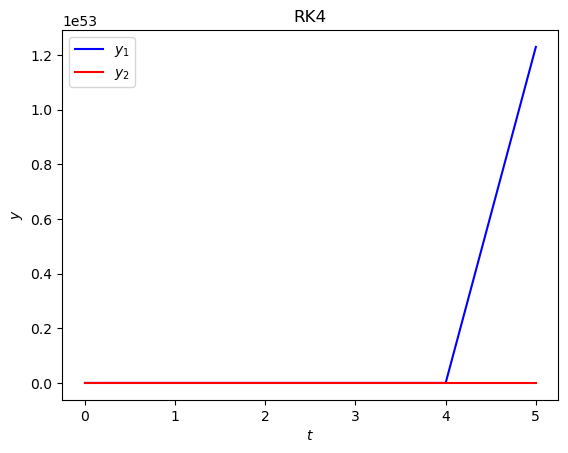

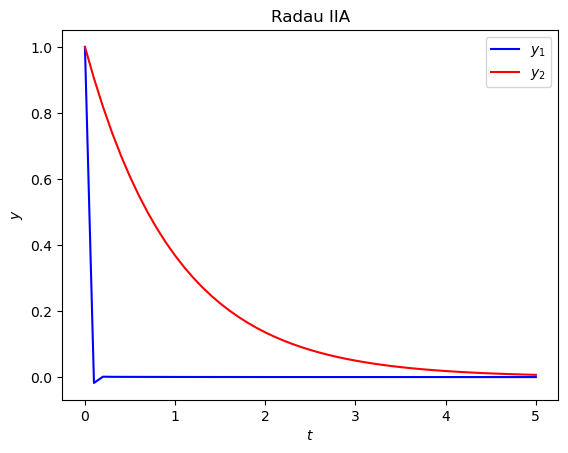

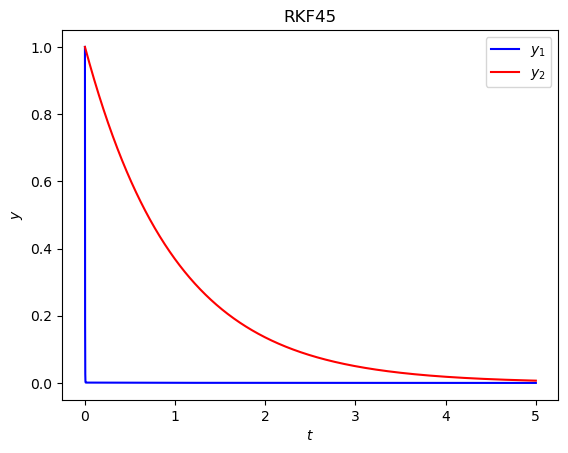

In [ ]:

# Plot solution
fig, ax = plt.subplots()
plt.plot(t_rk4, y_rk4[:,0], "b", label="$y_1$")
plt.plot(t_rk4, y_rk4[:,1], "r", label="$y_2$")
plt.xlabel("$t$")
plt.ylabel("$y$")
plt.title("RK4")
plt.legend()
plt.show()

from myst_nb import glue
glue("ex3.3_plot_rk4", fig, display=False)

# Plot solution
fig, ax = plt.subplots()
plt.plot(t, y_radauIIA[:,0], "b", label="$y_1$")
plt.plot(t, y_radauIIA[:,1], "r", label="$y_2$")
plt.xlabel("$t$")
plt.ylabel("$y$")
plt.title("Radau IIA")
plt.legend()
plt.show()

from myst_nb import glue
glue("ex3.3_plot_radauIIA", fig, display=False)

---
## Solutions

The solutions to these exercises downloaded below by right clicking on the link and select 'Save Link As':

- {Download}`Jupyer Notebook<../Python/chapter3_exercises.ipynb>`
- {Download}`MATLAB Live Script<../MATLAB/chapter3_exercises.mlx>`